# Healthcare Utilization Analytics
## Data Exploration and Quality Assessment

This notebook is the first stage of a healthcare utilization analytics project using synthetic patient data from Synthea.

The goal of this notebook is to:
- understand the structure of the patient, encounter, condition, and procedure data
- check for common data-quality issues
- prepare date fields for analysis
- create a few useful analytical features
- explore patient demographics, encounter utilization, and healthcare costs

## 1. Setup

I start by importing the libraries used for data manipulation and basic exploratory visualization.


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Load the Data

The project uses four Synthea CSV files:

- patients — one record per synthetic patient
- encounters — healthcare visits and associated costs
- conditions — diagnoses or conditions recorded for patients
- procedures — procedures associated with healthcare encounters

Relative file paths are used


In [88]:
patients = pd.read_csv("../data/raw/patients.csv")
encounters = pd.read_csv("../data/raw/encounters.csv")
conditions = pd.read_csv("../data/raw/conditions.csv")
procedures = pd.read_csv("../data/raw/procedures.csv")


## 3. Initial Data Review

Before cleaning anything, I review the size, column structure, and first few records of each dataset. This helps establish what one row represents and which fields can be used to connect the tables.


In [89]:
print("Patients:  ", patients.shape)
print("Encounters:", encounters.shape)
print("Conditions:", conditions.shape)
print("Procedures:", procedures.shape)


Patients:   (1171, 25)
Encounters: (53346, 15)
Conditions: (8376, 6)
Procedures: (34981, 8)


In [90]:
patients.head()


,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,1d604da9-9a81-4ba9-80c2-de3375d59b40,1989-05-25,NaN,999-76-6866,S99984236,X19277260X,Mr.,José Eduardo181,Gómez206,NaN,...,Marigot Saint Andrew Parish DM,427 Balistreri Way Unit 19,Chicopee,Massachusetts,Hampden County,1013.0,42.228354,-72.562951,271227.08,1334.88
1,034e9e3b-2def-4559-bb2a-7850888ae060,1983-11-14,NaN,999-73-5361,S99962402,X88275464X,Mr.,Milo271,Feil794,NaN,...,Danvers Massachusetts US,422 Farrell Path Unit 69,Somerville,Massachusetts,Middlesex County,2143.0,42.360697,-71.126531,793946.01,3204.49
2,10339b10-3cd1-4ac3-ac13-ec26728cb592,1992-06-02,NaN,999-27-3385,S99972682,X73754411X,Mr.,Jayson808,Fadel536,NaN,...,Springfield Massachusetts US,1056 Harris Lane Suite 70,Chicopee,Massachusetts,Hampden County,1020.0,42.181642,-72.608842,574111.90,2606.40
3,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,1978-05-27,NaN,999-85-4926,S99974448,X40915583X,Mrs.,Mariana775,Rutherford999,NaN,...,Yarmouth Massachusetts US,999 Kuhn Forge,Lowell,Massachusetts,Middlesex County,1851.0,42.636143,-71.343255,935630.30,8756.19
4,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,1996-10-18,NaN,999-60-7372,S99915787,X86772962X,Mr.,Gregorio366,Auer97,NaN,...,Patras Achaea GR,1050 Lindgren Extension Apt 38,Boston,Massachusetts,Suffolk County,2135.0,42.352434,-71.028610,598763.07,3772.20


In [91]:
encounters.head()


,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,d0c40d10-8d87-447e-836e-99d26ad52ea5,2010-01-23T17:45:28Z,2010-01-23T18:10:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,e002090d-4e92-300e-b41e-7d1f21dee4c6,e6283e46-fd81-3611-9459-0edb1c3da357,6e2f1a2d-27bd-3701-8d08-dae202c58632,ambulatory,185345009,Encounter for symptom,129.16,129.16,54.16,10509002.0,Acute bronchitis (disorder)
1,e88bc3a9-007c-405e-aabc-792a38f4aa2b,2012-01-23T17:45:28Z,2012-01-23T18:00:28Z,034e9e3b-2def-4559-bb2a-7850888ae060,772ee193-bb9f-30eb-9939-21e86c8e4da5,6f1d59a7-a5bd-3cf9-9671-5bad2f351c28,6e2f1a2d-27bd-3701-8d08-dae202c58632,wellness,162673000,General examination of patient (procedure),129.16,129.16,129.16,NaN,NaN
2,8f104aa7-4ca9-4473-885a-bba2437df588,2001-05-01T15:02:18Z,2001-05-01T15:17:18Z,1d604da9-9a81-4ba9-80c2-de3375d59b40,5d4b9df1-93ae-3bc9-b680-03249990e558,af01a385-31d3-3c77-8fdb-2867fe88df2f,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185345009,Encounter for symptom,129.16,129.16,0.00,36971009.0,Sinusitis (disorder)
3,b85c339a-6076-43ed-b9d0-9cf013dec49d,2011-07-28T15:02:18Z,2011-07-28T15:17:18Z,1d604da9-9a81-4ba9-80c2-de3375d59b40,3dc9bb2d-5d66-3e61-bf9a-e234c6433577,bb17e691-262b-3546-93d5-d88e7de93246,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),129.16,129.16,0.00,NaN,NaN
4,dae2b7cb-1316-4b78-954f-fa610a6c6d0e,2010-07-27T12:58:08Z,2010-07-27T13:28:08Z,10339b10-3cd1-4ac3-ac13-ec26728cb592,b03dba4f-892f-365c-bfd1-bfcfa7a98d5d,7ed6b84a-b847-3744-9d42-15c42297a0c2,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,General examination of patient (procedure),129.16,129.16,129.16,NaN,NaN


In [92]:
conditions.head()


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2001-05-01,NaN,1d604da9-9a81-4ba9-80c2-de3375d59b40,8f104aa7-4ca9-4473-885a-bba2437df588,40055000,Chronic sinusitis (disorder)
1,2011-08-09,2011-08-16,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,9d35ec9f-352a-4629-92ef-38eae38437e7,444814009,Viral sinusitis (disorder)
2,2011-11-16,2011-11-26,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,ae7555a9-eaff-4c09-98a7-21bc6ed1b1fd,195662009,Acute viral pharyngitis (disorder)
3,2011-05-13,2011-05-27,10339b10-3cd1-4ac3-ac13-ec26728cb592,e1ab4933-07a1-49f0-b4bd-05500919061d,10509002,Acute bronchitis (disorder)
4,2011-02-06,2011-02-14,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,b8f76eba-7795-4dcd-a544-f27ac2ef3d46,195662009,Acute viral pharyngitis (disorder)


In [93]:
procedures.head()


,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-04-30T00:26:23Z,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,6aa37300-d1b4-48e7-a2f8-5e0f70f48f38,169553002,Insertion of subcutaneous contraceptive,14896.56,NaN,NaN
1,2010-07-27T12:58:08Z,10339b10-3cd1-4ac3-ac13-ec26728cb592,dae2b7cb-1316-4b78-954f-fa610a6c6d0e,430193006,Medication Reconciliation (procedure),726.51,NaN,NaN
2,2010-11-20T03:04:34Z,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,7ff86631-0378-4bfc-92ce-1edd697eb18e,430193006,Medication Reconciliation (procedure),788.50,NaN,NaN
3,2011-02-07T03:04:34Z,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,b8f76eba-7795-4dcd-a544-f27ac2ef3d46,117015009,Throat culture (procedure),2070.44,195662009.0,Acute viral pharyngitis (disorder)
4,2011-04-19T03:04:34Z,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,640837d9-845a-433c-9fad-47426664a69d,117015009,Throat culture (procedure),2479.39,195662009.0,Acute viral pharyngitis (disorder)


### Column Structure


In [94]:
print("PATIENTS")
print(patients.columns.tolist())

print("\nENCOUNTERS")
print(encounters.columns.tolist())

print("\nCONDITIONS")
print(conditions.columns.tolist())

print("\nPROCEDURES")
print(procedures.columns.tolist())


PATIENTS
['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']

ENCOUNTERS
['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']

CONDITIONS
['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']

PROCEDURES
['DATE', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION']


### Data Types

I also inspect the patient and encounter tables to identify fields that need type conversion. In particular, CSV files commonly load dates as text rather than true datetime values.


In [95]:
patients.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   1171 non-null   object 
 1   BIRTHDATE            1171 non-null   object 
 2   DEATHDATE            171 non-null    object 
 3   SSN                  1171 non-null   object 
 4   DRIVERS              958 non-null    object 
 5   PASSPORT             898 non-null    object 
 6   PREFIX               927 non-null    object 
 7   FIRST                1171 non-null   object 
 8   LAST                 1171 non-null   object 
 9   SUFFIX               12 non-null     object 
 10  MAIDEN               331 non-null    object 
 11  MARITAL              791 non-null    object 
 12  RACE                 1171 non-null   object 
 13  ETHNICITY            1171 non-null   object 
 14  GENDER               1171 non-null   object 
 15  BIRTHPLACE           1171 non-null   o

In [96]:
encounters.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53346 entries, 0 to 53345
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   53346 non-null  object 
 1   START                53346 non-null  object 
 2   STOP                 53346 non-null  object 
 3   PATIENT              53346 non-null  object 
 4   ORGANIZATION         53346 non-null  object 
 5   PROVIDER             53346 non-null  object 
 6   PAYER                53346 non-null  object 
 7   ENCOUNTERCLASS       53346 non-null  object 
 8   CODE                 53346 non-null  int64  
 9   DESCRIPTION          53346 non-null  object 
 10  BASE_ENCOUNTER_COST  53346 non-null  float64
 11  TOTAL_CLAIM_COST     53346 non-null  float64
 12  PAYER_COVERAGE       53346 non-null  float64
 13  REASONCODE           13777 non-null  float64
 14  REASONDESCRIPTION    13777 non-null  object 
dtypes: float64(4), int64(1), object(10)


## 4. Data Quality Assessment

Before doing any analysis, I check for missing values, duplicate records, duplicate primary identifiers, and broken patient references.


In [97]:
def missing_report(df):
    report = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_percent": (df.isnull().mean() * 100).round(2)
    })

    return report.sort_values("missing_percent", ascending=False)


### Missing Values


In [98]:
missing_report(patients)


,missing_count,missing_percent
SUFFIX,1159,98.98
DEATHDATE,1000,85.40
MAIDEN,840,71.73
ZIP,543,46.37
MARITAL,380,32.45
PASSPORT,273,23.31
PREFIX,244,20.84
DRIVERS,213,18.19
Id,0,0.00
LAST,0,0.00


In [99]:
missing_report(encounters)


,missing_count,missing_percent
REASONCODE,39569,74.17
REASONDESCRIPTION,39569,74.17
Id,0,0.00
PATIENT,0,0.00
ORGANIZATION,0,0.00
START,0,0.00
STOP,0,0.00
PAYER,0,0.00
PROVIDER,0,0.00
ENCOUNTERCLASS,0,0.00


In [100]:
missing_report(conditions)


,missing_count,missing_percent
STOP,3811,45.5
START,0,0.0
PATIENT,0,0.0
ENCOUNTER,0,0.0
CODE,0,0.0
DESCRIPTION,0,0.0


In [101]:
missing_report(procedures)


,missing_count,missing_percent
REASONCODE,15544,44.44
REASONDESCRIPTION,15544,44.44
DATE,0,0.00
PATIENT,0,0.00
CODE,0,0.00
ENCOUNTER,0,0.00
BASE_COST,0,0.00
DESCRIPTION,0,0.00


### Duplicate Records

A full-row duplicate is different from seeing the same patient or encounter reference multiple times. For example, one patient is expected to have many encounters, so repeated patient values in the encounter table are legitimate.


In [102]:
print("Duplicate patient rows:  ", patients.duplicated().sum())
print("Duplicate encounter rows:", encounters.duplicated().sum())
print("Duplicate condition rows: ", conditions.duplicated().sum())
print("Duplicate procedure rows: ", procedures.duplicated().sum())


Duplicate patient rows:   0
Duplicate encounter rows: 0
Duplicate condition rows:  0
Duplicate procedure rows:  0


In [103]:
print("Duplicate patient IDs:  ", patients["Id"].duplicated().sum())
print("Duplicate encounter IDs:", encounters["Id"].duplicated().sum())


Duplicate patient IDs:   0
Duplicate encounter IDs: 0


## 5. Basic Patient and Clinical Profile

I use frequency counts to get a quick sense of the synthetic patient population and the most frequently recorded conditions and procedures.


In [104]:
patients["GENDER"].value_counts()


GENDER
F    609
M    562
Name: count, dtype: int64

In [105]:
patients["RACE"].value_counts()


RACE
white     965
black     101
asian      90
native     13
other       2
Name: count, dtype: int64

In [106]:
patients["ETHNICITY"].value_counts()


ETHNICITY
nonhispanic    1058
hispanic        113
Name: count, dtype: int64

In [107]:
conditions["DESCRIPTION"].value_counts().head(20)


DESCRIPTION
Viral sinusitis (disorder)                  1248
Acute viral pharyngitis (disorder)           653
Acute bronchitis (disorder)                  563
Normal pregnancy                             516
Body mass index 30+ - obesity (finding)      449
Prediabetes                                  317
Hypertension                                 302
Anemia (disorder)                            300
Chronic sinusitis (disorder)                 236
Miscarriage in first trimester               221
Otitis media                                 196
Streptococcal sore throat (disorder)         157
Hyperlipidemia                               136
Sprain of ankle                              134
Polyp of colon                                79
Concussion with no loss of consciousness      77
Diabetes                                      76
Metabolic syndrome X (disorder)               74
Hypertriglyceridemia (disorder)               74
Acute bacterial sinusitis (disorder)          69
Name: co

In [108]:
procedures["DESCRIPTION"].value_counts().head(20)


DESCRIPTION
Medication Reconciliation (procedure)                                        5632
Renal dialysis (procedure)                                                   3389
Auscultation of the fetal heart                                              2705
Evaluation of uterine fundal height                                          2705
Subcutaneous immunotherapy                                                   1497
Intramuscular injection                                                      1324
Electrical cardioversion                                                      981
Combined chemotherapy and radiation therapy (procedure)                       655
Hemoglobin / Hematocrit / Platelet count                                      602
Colonoscopy                                                                   527
Ultrasound scan for fetal viability                                           474
Standard pregnancy test                                                       474
Depr

## 6. Date Preparation and Feature Engineering

The date fields are converted from text to pandas datetime values. This allows calculations such as patient age and encounter duration.


In [109]:
patients["BIRTHDATE"] = pd.to_datetime(
    patients["BIRTHDATE"],
    errors="coerce"
)

patients["DEATHDATE"] = pd.to_datetime(
    patients["DEATHDATE"],
    errors="coerce"
)

encounters["START"] = pd.to_datetime(
    encounters["START"],
    errors="coerce"
)

encounters["STOP"] = pd.to_datetime(
    encounters["STOP"],
    errors="coerce"
)

conditions["START"] = pd.to_datetime(
    conditions["START"],
    errors="coerce"
)

conditions["STOP"] = pd.to_datetime(
    conditions["STOP"],
    errors="coerce"
)

procedures["DATE"] = pd.to_datetime(
    procedures["DATE"],
    errors="coerce"
)


In [110]:
print("Earliest encounter:", encounters["START"].min())
print("Latest encounter:  ", encounters["START"].max())


Earliest encounter: 1912-07-21 19:05:21+00:00
Latest encounter:   2020-04-28 18:58:37+00:00


### Patient Age

Rather than calculating age using today's date, I use the latest encounter date in the dataset as the analysis date. This keeps age aligned with the period represented by the healthcare data.


In [111]:
analysis_date = encounters["START"].max()

# Remove timezone information from the analysis date if present
if analysis_date.tzinfo is not None:
    analysis_date_for_age = analysis_date.tz_localize(None)
else:
    analysis_date_for_age = analysis_date

patients["AGE"] = (
    (analysis_date_for_age - patients["BIRTHDATE"]).dt.days / 365.25
)


In [112]:
patients["AGE"].describe()


count    1171.000000
mean       44.708664
std        26.723091
min         0.101300
25%        22.626968
50%        43.723477
75%        63.746749
max       110.349076
Name: AGE, dtype: float64

As a basic validation step, I check for impossible ages. Values below 0 or above 120 would be flagged for investigation.


In [113]:
patients[
    (patients["AGE"] < 0) |
    (patients["AGE"] > 120)
]


,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE


### Age Groups

Age is grouped into broader categories that will be easier to use in later SQL analysis and Power BI reporting.


In [114]:
patients["AGE_GROUP"] = pd.cut(
    patients["AGE"],
    bins=[-1, 17, 34, 49, 64, 79, 120],
    labels=[
        "0-17",
        "18-34",
        "35-49",
        "50-64",
        "65-79",
        "80+"
    ]
)

patients[["AGE", "AGE_GROUP"]].head(10)


,AGE,AGE_GROUP
0,30.926762,18-34
1,36.454483,35-49
2,27.904175,18-34
3,41.921971,35-49
4,23.526352,18-34
5,2.754278,0-17
6,16.375086,0-17
7,0.955510,0-17
8,49.952088,50-64
9,3.816564,0-17


In [115]:
patients["AGE_GROUP"].value_counts().sort_index()


AGE_GROUP
0-17     212
18-34    245
35-49    215
50-64    210
65-79    162
80+      127
Name: count, dtype: int64

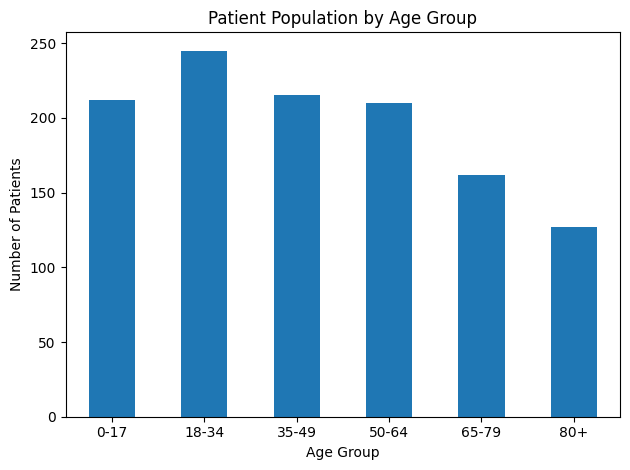

In [116]:
patients["AGE_GROUP"].value_counts().sort_index().plot(kind="bar")

plt.title("Patient Population by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Encounter Duration

Encounter duration is calculated in hours using the difference between the encounter stop and start timestamps. Negative durations are treated as a data-quality issue because an encounter should not end before it begins.


In [117]:
encounters["ENCOUNTER_DURATION_HOURS"] = (
    encounters["STOP"] - encounters["START"]
).dt.total_seconds() / 3600

encounters[
    ["START", "STOP", "ENCOUNTER_DURATION_HOURS"]
].head(10)


,START,STOP,ENCOUNTER_DURATION_HOURS
0,2010-01-23 17:45:28+00:00,2010-01-23 18:10:28+00:00,0.416667
1,2012-01-23 17:45:28+00:00,2012-01-23 18:00:28+00:00,0.250000
2,2001-05-01 15:02:18+00:00,2001-05-01 15:17:18+00:00,0.250000
3,2011-07-28 15:02:18+00:00,2011-07-28 15:17:18+00:00,0.250000
4,2010-07-27 12:58:08+00:00,2010-07-27 13:28:08+00:00,0.500000
5,2010-05-05 00:26:23+00:00,2010-05-05 01:11:23+00:00,0.750000
6,2011-04-30 00:26:23+00:00,2011-04-30 01:03:23+00:00,0.616667
7,2011-08-10 00:26:23+00:00,2011-08-10 00:41:23+00:00,0.250000
8,2011-11-17 00:26:23+00:00,2011-11-17 00:41:23+00:00,0.250000
9,2012-04-24 00:26:23+00:00,2012-04-24 00:41:23+00:00,0.250000


In [118]:
encounters["ENCOUNTER_DURATION_HOURS"].describe()


count     53346.000000
mean        524.822047
std       13926.763423
min           0.250000
25%           0.250000
50%           0.450000
75%           0.750000
max      766080.250000
Name: ENCOUNTER_DURATION_HOURS, dtype: float64

In [119]:
encounters[
    encounters["ENCOUNTER_DURATION_HOURS"] < 0
]


,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,ENCOUNTER_DURATION_HOURS


## 7. Healthcare Utilization

Encounter class provides a high-level view of how patients are interacting with the healthcare system.


In [120]:
encounter_counts = encounters["ENCOUNTERCLASS"].value_counts()
encounter_counts


ENCOUNTERCLASS
wellness      19106
ambulatory    18936
outpatient     9003
urgentcare     2373
emergency      2090
inpatient      1838
Name: count, dtype: int64

In [121]:
encounter_percent = (
    encounters["ENCOUNTERCLASS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

encounter_percent


ENCOUNTERCLASS
wellness      35.82
ambulatory    35.50
outpatient    16.88
urgentcare     4.45
emergency      3.92
inpatient      3.45
Name: proportion, dtype: float64

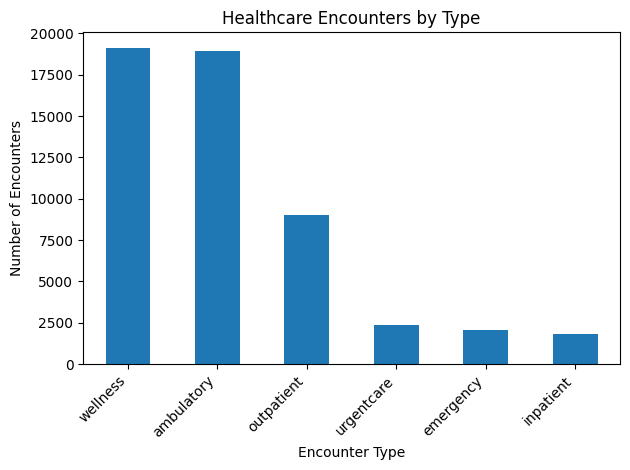

In [122]:
encounter_counts.plot(kind="bar")

plt.title("Healthcare Encounters by Type")
plt.xlabel("Encounter Type")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Encounter Cost Analysis

I review the available encounter-level cost fields and summarize total claim cost by encounter class. Because this is synthetic data, these values are best treated as analytical examples rather than estimates of real-world healthcare prices.


In [123]:
encounters[
    [
        "BASE_ENCOUNTER_COST",
        "TOTAL_CLAIM_COST",
        "PAYER_COVERAGE"
    ]
].describe()


,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE
count,53346.000000,53346.000000,53346.000000
mean,128.750290,128.750290,61.998867
std,4.582823,4.582823,43.613335
min,77.490000,77.490000,0.000000
25%,129.160000,129.160000,17.490000
50%,129.160000,129.160000,69.160000
75%,129.160000,129.160000,89.160000
max,129.160000,129.160000,129.160000


### Highest-Cost Encounters


In [124]:
encounters[
    [
        "PATIENT",
        "ENCOUNTERCLASS",
        "DESCRIPTION",
        "TOTAL_CLAIM_COST"
    ]
].sort_values(
    "TOTAL_CLAIM_COST",
    ascending=False
).head(20)


,PATIENT,ENCOUNTERCLASS,DESCRIPTION,TOTAL_CLAIM_COST
53345,fc817953-cc8b-45db-9c85-7c0ced8fa90d,wellness,General examination of patient (procedure),129.16
0,034e9e3b-2def-4559-bb2a-7850888ae060,ambulatory,Encounter for symptom,129.16
53306,fca3178e-fb68-41c3-8598-702d3ca68b96,ambulatory,Encounter for 'check-up',129.16
53307,fca3178e-fb68-41c3-8598-702d3ca68b96,wellness,General examination of patient (procedure),129.16
53308,fca3178e-fb68-41c3-8598-702d3ca68b96,wellness,General examination of patient (procedure),129.16
53309,fca3178e-fb68-41c3-8598-702d3ca68b96,wellness,General examination of patient (procedure),129.16
53310,fca3178e-fb68-41c3-8598-702d3ca68b96,emergency,Emergency room admission (procedure),129.16
53311,fca3178e-fb68-41c3-8598-702d3ca68b96,wellness,General examination of patient (procedure),129.16
53312,fca3178e-fb68-41c3-8598-702d3ca68b96,emergency,Emergency room admission (procedure),129.16
53313,fca3178e-fb68-41c3-8598-702d3ca68b96,ambulatory,Encounter for 'check-up',129.16


### Cost by Encounter Type


In [125]:
cost_by_encounter = (
    encounters
    .groupby("ENCOUNTERCLASS")["TOTAL_CLAIM_COST"]
    .agg(
        encounter_count="count",
        average_cost="mean",
        total_cost="sum"
    )
    .reset_index()
    .sort_values("total_cost", ascending=False)
)

cost_by_encounter


,ENCOUNTERCLASS,encounter_count,average_cost,total_cost
5,wellness,19106,129.160000,2467730.96
0,ambulatory,18936,129.160000,2445773.76
3,outpatient,9003,129.160000,1162827.48
4,urgentcare,2373,129.160000,306496.68
1,emergency,2090,129.160000,269944.40
2,inpatient,1838,117.268591,215539.67


## 9. Referential Integrity

Every encounter should point to a patient that exists in the patient table. This check identifies encounter records whose patient ID cannot be matched to `patients.Id`.


In [126]:
invalid_patient_references = encounters[
    ~encounters["PATIENT"].isin(patients["Id"])
]

invalid_patient_references.shape


(0, 16)

## 10. Data Quality Summary

The main validation checks are brought together into a small quality report that can be saved as a project output.


In [127]:
quality_report = pd.DataFrame({
    "Quality Check": [
        "Duplicate patient IDs",
        "Duplicate encounter IDs",
        "Missing encounter patient IDs",
        "Invalid patient references",
        "Negative encounter durations"
    ],
    "Records Flagged": [
        patients["Id"].duplicated().sum(),
        encounters["Id"].duplicated().sum(),
        encounters["PATIENT"].isnull().sum(),
        len(invalid_patient_references),
        (encounters["ENCOUNTER_DURATION_HOURS"] < 0).sum()
    ]
})

quality_report


,Quality Check,Records Flagged
0,Duplicate patient IDs,0
1,Duplicate encounter IDs,0
2,Missing encounter patient IDs,0
3,Invalid patient references,0
4,Negative encounter durations,0


In [128]:
quality_report.to_csv(
    "../data/processed/data_quality_report.csv",
    index=False
)


## 11. Initial Observations

A few early observations from the exploratory analysis:

- The dataset contains 1,171 synthetic patients with a median age of about 43 years at the end of the analysis period.
- Wellness and ambulatory visits make up the largest encounter categories, while emergency and inpatient encounters occur less frequently.
- The primary patient and encounter identifiers passed the duplicate checks performed in this notebook.
- No missing encounter patient IDs, invalid patient references, or negative encounter durations were identified in the initial quality checks.
- Encounter costs are available for later utilization and cost analysis, although the synthetic nature of the dataset should be kept in mind when interpreting dollar amounts.

The next stage of the project will move the prepared data into PostgreSQL and use SQL to analyze utilization, high-use patient groups, chronic disease burden, costs, and readmissions.


## Export Database-Ready Files

Rename columns to consistent database-friendly names.

In [ ]:
patients_clean = patients[
    [
        "Id",
        "BIRTHDATE",
        "DEATHDATE",
        "RACE",
        "ETHNICITY",
        "GENDER",
        "CITY",
        "STATE",
        "COUNTY",
        "ZIP",
        "HEALTHCARE_EXPENSES",
        "HEALTHCARE_COVERAGE"
    ]
].copy()

patients_clean.columns = [
    "patient_id",
    "birth_date",
    "death_date",
    "race",
    "ethnicity",
    "gender",
    "city",
    "state",
    "county",
    "zip",
    "healthcare_expenses",
    "healthcare_coverage"
]

patients_clean.head()

In [ ]:
patients_clean.to_csv(
    "../data/processed/patients_clean.csv",
    index=False
)

In [ ]:
encounters_clean = encounters[
    [
        "Id",
        "START",
        "STOP",
        "PATIENT",
        "ENCOUNTERCLASS",
        "DESCRIPTION",
        "BASE_ENCOUNTER_COST",
        "TOTAL_CLAIM_COST",
        "PAYER_COVERAGE"
    ]
].copy()

encounters_clean.columns = [
    "encounter_id",
    "start_time",
    "stop_time",
    "patient_id",
    "encounter_class",
    "description",
    "base_encounter_cost",
    "total_claim_cost",
    "payer_coverage"
]

encounters_clean.head()

In [ ]:
encounters_clean.to_csv(
    "../data/processed/encounters_clean.csv",
    index=False
)

In [ ]:
conditions_clean = conditions[
    [
        "START",
        "STOP",
        "PATIENT",
        "ENCOUNTER",
        "CODE",
        "DESCRIPTION"
    ]
].copy()

conditions_clean.columns = [
    "start_date",
    "stop_date",
    "patient_id",
    "encounter_id",
    "condition_code",
    "condition_description"
]

conditions_clean.head()

In [ ]:
conditions_clean.to_csv(
    "../data/processed/conditions_clean.csv",
    index=False
)

In [ ]:
procedures_clean = procedures[
    [
        "DATE",
        "PATIENT",
        "ENCOUNTER",
        "CODE",
        "DESCRIPTION",
        "BASE_COST"
    ]
].copy()

procedures_clean.columns = [
    "procedure_date",
    "patient_id",
    "encounter_id",
    "procedure_code",
    "procedure_description",
    "base_cost"
]

procedures_clean.head()

In [ ]:
procedures_clean.to_csv(
    "../data/processed/procedures_clean.csv",
    index=False
)